In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1) Imports


In [ ]:
import os
import random
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

from PIL import Image

print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow version: 2.19.0
GPU available: True


## 2) Configuration (seed, image size, paths)


In [ ]:
SEED = 123
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

IMG_SIZE = (256, 256)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

CLASSES = ["glass", "metal", "plastic"]

# TODO: CHANGE THESE PATHS
PUBLIC_DIR = r"/content/drive/MyDrive/TCV6313-COMPUTER VISION/TCV project/public_trainval"
PRIVATE_DIR = r"/content/drive/MyDrive/TCV6313-COMPUTER VISION/TCV project/private_test_512"

public_ok = os.path.isdir(PUBLIC_DIR)
private_ok = os.path.isdir(PRIVATE_DIR)

print("PUBLIC_DIR :", PUBLIC_DIR, "->", "OK" if public_ok else "NOT FOUND")
print("PRIVATE_DIR:", PRIVATE_DIR, "->", "OK" if private_ok else "NOT FOUND")

if not public_ok:
    print("\n[STOP] Public dataset folder not found. Please update PUBLIC_DIR above.")

PUBLIC_DIR : /content/drive/MyDrive/TCV6313-COMPUTER VISION/TCV project/public_trainval -> OK
PRIVATE_DIR: /content/drive/MyDrive/TCV6313-COMPUTER VISION/TCV project/private_test_512 -> OK


## 3) Public dataset preprocessing (null/empty + corrupt image checks)


In [ ]:
from PIL import Image

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def preprocess_public_dataset(root_dir, class_names, move_bad=True):
    """Basic preprocessing/quality checks for the PUBLIC dataset.

    Checks:
    1) Missing class folders
    2) Empty files (size = 0)  -> treated as "null"
    3) Corrupted/unreadable image files (PIL verify)

    If move_bad=True, bad files are moved to: <root_dir>/_bad_files/<class_name>/...
    """
    root = Path(root_dir)
    bad_dir = root / "_bad_files"
    bad_dir.mkdir(exist_ok=True)

    summary = {c: {"total": 0, "empty": 0, "corrupt": 0} for c in class_names}
    bad_files = []

    for c in class_names:
        class_path = root / c
        if not class_path.exists():
            print(f"[WARN] Missing class folder: {class_path}")
            continue

        for p in class_path.iterdir():
            if p.is_dir():
                continue
            if p.suffix.lower() not in IMG_EXTS:
                continue

            summary[c]["total"] += 1

            # (A) empty file check ("null" file)
            try:
                if p.stat().st_size == 0:
                    summary[c]["empty"] += 1
                    bad_files.append(p)
                    continue
            except OSError:
                summary[c]["empty"] += 1
                bad_files.append(p)
                continue

            # (B) corrupt image check
            try:
                with Image.open(p) as im:
                    im.verify()
            except Exception:
                summary[c]["corrupt"] += 1
                bad_files.append(p)

    # Move bad files away from training folder
    if move_bad and bad_files:
        for p in bad_files:
            rel = p.relative_to(root)  # class_name/filename.ext
            dest = bad_dir / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            try:
                shutil.move(str(p), str(dest))
            except Exception as e:
                print(f"[WARN] Could not move {p}: {e}")

    # Print + return a nice table
    df = pd.DataFrame(summary).T.reset_index().rename(columns={"index": "class"})
    df["bad_total"] = df["empty"] + df["corrupt"]

    print("\n=== PUBLIC PREPROCESSING SUMMARY ===")
    display(df)

    if move_bad:
        print("Bad files moved to:", str(bad_dir))
    else:
        print("Bad files were NOT moved (move_bad=False).")

    return df

if public_ok:
    preprocess_df = preprocess_public_dataset(PUBLIC_DIR, CLASSES, move_bad=True)
else:
    preprocess_df = None


=== PUBLIC PREPROCESSING SUMMARY ===


,class,total,empty,corrupt,bad_total
0,glass,1998,0,0,0
1,metal,993,0,0,0
2,plastic,1709,0,0,0


Bad files moved to: /content/drive/MyDrive/TCV6313-COMPUTER VISION/TCV project/public_trainval/_bad_files


## 4) Public dataset class counts (after preprocessing)


,class,num_images
0,glass,1998
1,metal,993
2,plastic,1709


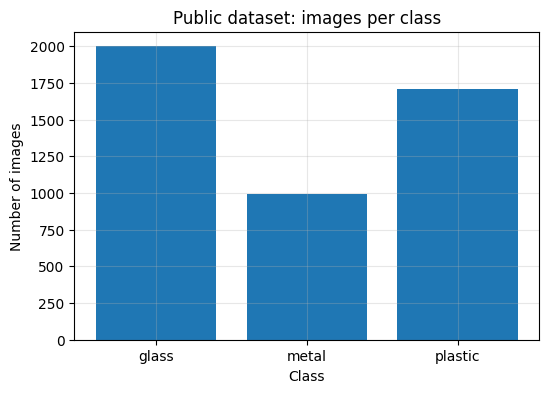

In [ ]:
def count_images_by_class(root_dir, class_names):
    root = Path(root_dir)
    counts = {}
    for c in class_names:
        class_path = root / c
        if not class_path.exists():
            counts[c] = 0
            continue
        n = 0
        for p in class_path.iterdir():
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                n += 1
        counts[c] = n
    return counts

if public_ok:
    counts = count_images_by_class(PUBLIC_DIR, CLASSES)
    counts_df = pd.DataFrame([counts]).T.reset_index()
    counts_df.columns = ["class", "num_images"]
    display(counts_df)

    plt.figure(figsize=(6, 4))
    plt.bar(counts_df["class"], counts_df["num_images"])
    plt.title("Public dataset: images per class")
    plt.xlabel("Class")
    plt.ylabel("Number of images")
    plt.grid(True, alpha=0.3)
    plt.show()

## 5) Build TRAIN / VAL datasets from PUBLIC folder


In [ ]:
if not public_ok:
    train_ds = val_ds = None
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        PUBLIC_DIR,
        labels="inferred",
        label_mode="categorical",
        class_names=CLASSES,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
        validation_split=0.2,
        subset="training",
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        PUBLIC_DIR,
        labels="inferred",
        label_mode="categorical",
        class_names=CLASSES,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
        validation_split=0.2,
        subset="validation",
    )

    print("Classes (fixed order):", CLASSES)
    print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
    print("Val batches  :", tf.data.experimental.cardinality(val_ds).numpy())


Found 4700 files belonging to 3 classes.
Using 3760 files for training.
Found 4700 files belonging to 3 classes.
Using 940 files for validation.
Classes (fixed order): ['glass', 'metal', 'plastic']
Train batches: 118
Val batches  : 30


## 6) Build TEST dataset from PRIVATE folder (final evaluation)


In [ ]:
if not private_ok:
    test_ds = None
    print("[SKIP] PRIVATE_DIR not found, so test dataset is skipped.")
else:
    test_ds = tf.keras.utils.image_dataset_from_directory(
        PRIVATE_DIR,
        labels="inferred",
        label_mode="categorical",
        class_names=CLASSES,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,  # keep order stable for evaluation
    )
    print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())


Found 472 files belonging to 3 classes.
Test batches: 15


## 7) Dataset pipeline preprocessing (simple & report-friendly)


In [ ]:
def basic_image_preprocess(x, y):
    x = tf.cast(x, tf.float32)
    x = tf.clip_by_value(x, 0.0, 255.0)
    return x, y

def optimize(ds):
    return ds.map(basic_image_preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

if train_ds is not None:
    train_ds = optimize(train_ds)
if val_ds is not None:
    val_ds = optimize(val_ds)
if test_ds is not None:
    test_ds = optimize(test_ds)

print("Preprocessing + caching/prefetch applied.")


Preprocessing + caching/prefetch applied.


## 8) Visual check: show a batch of training images


Batch images shape: (32, 256, 256, 3)
Batch labels shape: (32, 3)


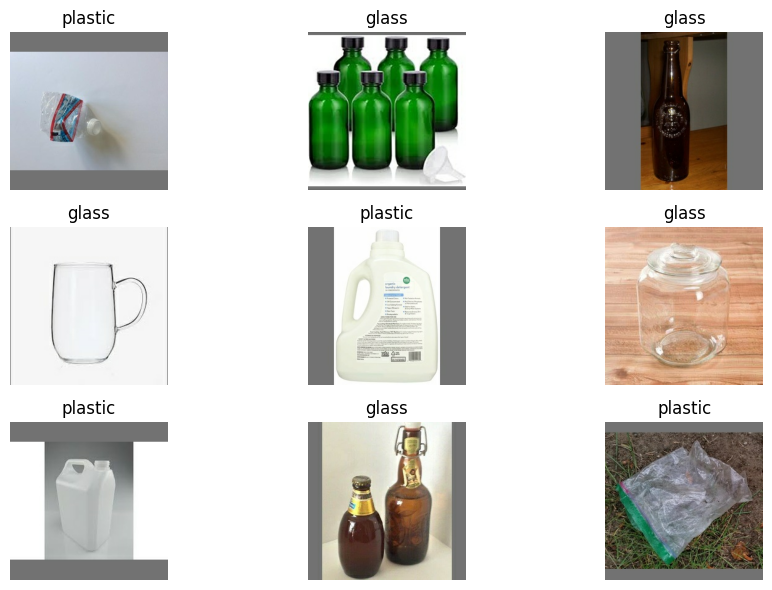

In [ ]:
if train_ds is None:
    print("[SKIP] No train_ds.")
else:
    plt.figure(figsize=(10, 6))
    for images, labels in train_ds.take(1):
        print("Batch images shape:", images.shape)
        print("Batch labels shape:", labels.shape)
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            label_idx = int(np.argmax(labels[i].numpy()))
            plt.title(CLASSES[label_idx])
            plt.axis("off")
    plt.tight_layout()
    plt.show()


## 9) Data augmentation (training only)


In [ ]:
USE_AUGMENTATION = True

augment = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
    ],
    name="augment",
)

print("Augmentation enabled:", USE_AUGMENTATION)


Augmentation enabled: True


## 10) Model builder (ResNet50 / VGG16 / MobileNetV2)


In [ ]:
def get_backbone_and_preprocess(model_name: str):
    name = model_name.lower()
    if name == "resnet50":
        backbone = tf.keras.applications.ResNet50
        preprocess = tf.keras.applications.resnet50.preprocess_input
        weights = "imagenet"
    elif name == "vgg16":
        backbone = tf.keras.applications.VGG16
        preprocess = tf.keras.applications.vgg16.preprocess_input
        weights = "imagenet"
    elif name == "mobilenetv2":
        backbone = tf.keras.applications.MobileNetV2
        preprocess = tf.keras.applications.mobilenet_v2.preprocess_input
        weights = "imagenet"
    else:
        raise ValueError("model_name must be one of: resnet50, vgg16, mobilenetv2")
    return backbone, preprocess, weights

def build_model(model_name: str, num_classes: int):
    backbone_fn, preprocess_input, weights = get_backbone_and_preprocess(model_name)

    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="input_image")

    # model-specific preprocess inside model (important for transfer learning)
    x = preprocess_input(inputs)

    if USE_AUGMENTATION:
        x = augment(x)

    base = backbone_fn(
        include_top=False,
        weights=weights,
        input_tensor=x,
        pooling="avg",
    )

    base.trainable = False  # LAB STYLE: frozen backbone

    x = layers.Dropout(0.2)(base.output)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=f"{model_name}_classifier")
    return model, base


## 11) Training function

In [ ]:
def train_model(model_name: str, epochs=30, lr=1e-4, patience=3):
    if train_ds is None or val_ds is None:
        raise RuntimeError("train_ds/val_ds not available. Check PUBLIC_DIR.")

    print("\n" + "=" * 70)
    print(f"TRAINING: {model_name.upper()} | epochs={epochs}, lr={lr}")
    print("=" * 70)

    model, base = build_model(model_name, num_classes=len(CLASSES))

    # ensure backbone frozen
    base.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    es = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[es],
        verbose=1
    )

    return model, history

## 12) Plot training curves (accuracy + loss)


In [ ]:
def plot_accuracy(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title(f"{title} — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_loss(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title(f"{title} — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 13) Train models (run one by one)


In [ ]:
trained = {}
histories = {}
print("Ready to train. Run the next cells to train each model.")

Ready to train. Run the next cells to train each model.


### 13.1 Train ResNet50


In [ ]:
if public_ok:
    model_resnet, hist_resnet = train_model("resnet50", epochs=30, lr=1e-4, patience=3)
    trained["resnet50"] = model_resnet
    histories["resnet50"] = hist_resnet


TRAINING: RESNET50 | epochs=30, lr=0.0001
Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 43s 255ms/step - accuracy: 0.3911 - loss: 1.3271 - val_accuracy: 0.6340 - val_loss: 0.8062
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 199ms/step - accuracy: 0.6365 - loss: 0.7921 - val_accuracy: 0.7670 - val_loss: 0.5900
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 198ms/step - accuracy: 0.7400 - loss: 0.6182 - val_accuracy: 0.8181 - val_loss: 0.4901
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 195ms/step - accuracy: 0.7847 - loss: 0.5369 - val_accuracy: 0.8394 - val_loss: 0.4269
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 194ms/step - accuracy: 0.8217 - loss: 0.4635 - val_accuracy: 0.8511 - val_loss: 0.3894
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 196ms/step - accuracy: 0.8338 - loss: 0.4268 - val_accuracy: 0.8638 - val_loss: 0.3632
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 196ms/step - accuracy: 0.8506 - loss: 0.3998 - val_accuracy: 0.8681 - val_loss: 0.3448
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 

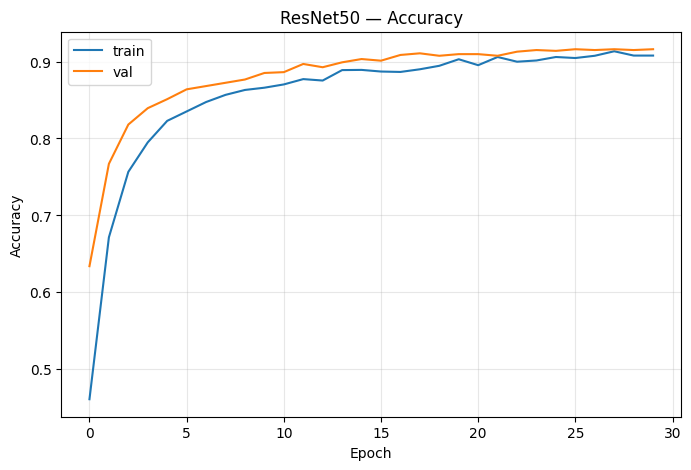

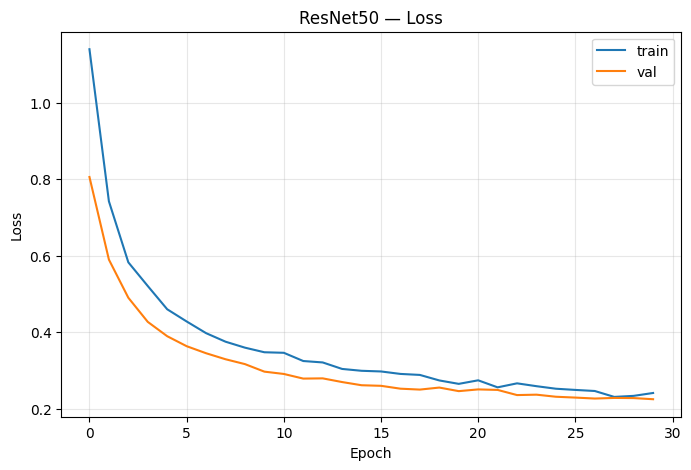

In [ ]:
plot_accuracy(hist_resnet, "ResNet50")
plot_loss(hist_resnet, "ResNet50")

### 13.2 Train VGG16


In [ ]:
if public_ok:
    model_vgg, hist_vgg = train_model("vgg16", epochs=30, lr=1e-4, patience=3)
    trained["vgg16"] = model_vgg
    histories["vgg16"] = hist_vgg


TRAINING: VGG16 | epochs=30, lr=0.0001
Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 34s 237ms/step - accuracy: 0.3337 - loss: 4.0587 - val_accuracy: 0.3691 - val_loss: 3.5111
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 24s 201ms/step - accuracy: 0.4150 - loss: 2.9489 - val_accuracy: 0.4309 - val_loss: 2.6242
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 24s 201ms/step - accuracy: 0.4588 - loss: 2.3382 - val_accuracy: 0.5064 - val_loss: 2.0551
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 24s 201ms/step - accuracy: 0.5095 - loss: 1.9823 - val_accuracy: 0.5734 - val_loss: 1.7063
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 24s 200ms/step - accuracy: 0.5484 - loss: 1.7700 - val_accuracy: 0.6138 - val_loss: 1.4498
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 24s 201ms/step - accuracy: 0.5849 - loss: 1.5013 - val_accuracy: 0.6479 - val_loss: 1.2616
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 24s 201ms/step - accuracy: 0.6273 - loss: 1.3214 - val_accuracy: 0.6745 - val_loss: 1.1498
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 24s

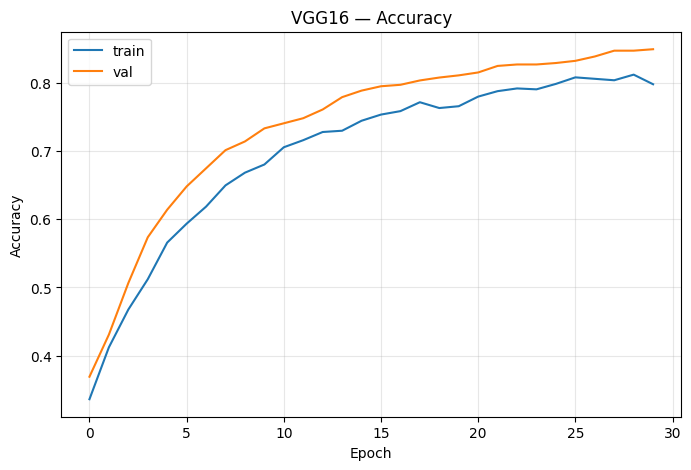

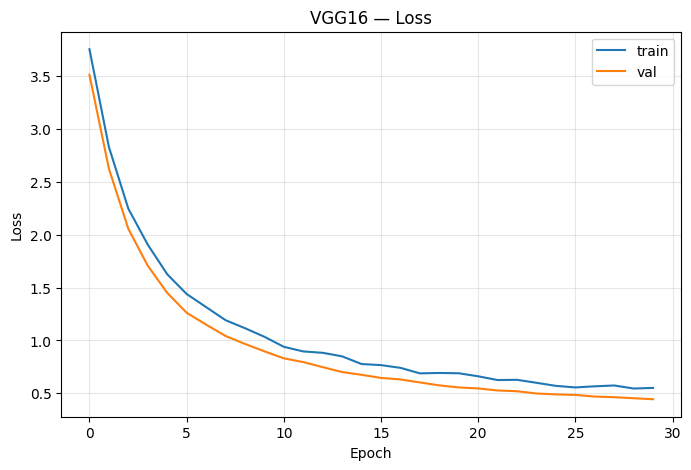

In [ ]:
plot_accuracy(hist_vgg, "VGG16")
plot_loss(hist_vgg, "VGG16")

### 13.3 Train MobileNetV2


In [ ]:
if public_ok:
    model_mnv2, hist_mnv2 = train_model("mobilenetv2", epochs=30, lr=1e-4, patience=3)
    trained["mobilenetv2"] = model_mnv2
    histories["mobilenetv2"] = hist_mnv2


TRAINING: MOBILENETV2 | epochs=30, lr=0.0001


/tmp/ipython-input-3398745059.py:30: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = backbone_fn(


Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.4146 - loss: 1.1800 - val_accuracy: 0.5979 - val_loss: 0.8993
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.5981 - loss: 0.8729 - val_accuracy: 0.6957 - val_loss: 0.7334
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - accuracy: 0.7001 - loss: 0.7193 - val_accuracy: 0.7457 - val_loss: 0.6412
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - accuracy: 0.7350 - loss: 0.6326 - val_accuracy: 0.7819 - val_loss: 0.5760
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.7585 - loss: 0.5897 - val_accuracy: 0.7830 - val_loss: 0.5384
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.7884 - loss: 0.5380 - val_accuracy: 0.8064 - val_loss: 0.5038
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.8096 - loss: 0.4975 - val_accuracy: 0.8160 - val_loss: 0.4819
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.8083 - loss: 0.4865 -

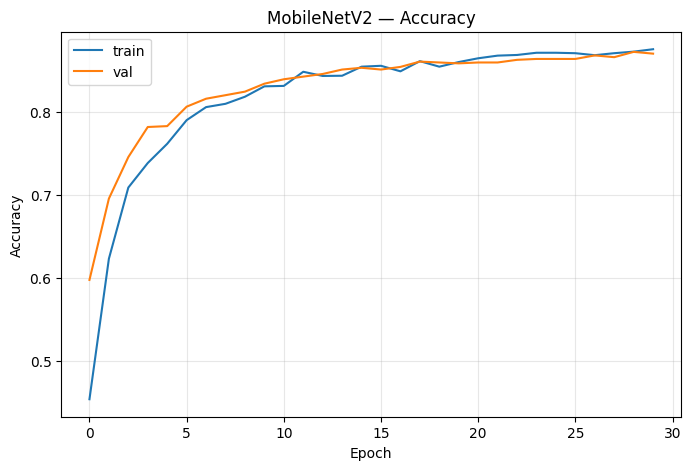

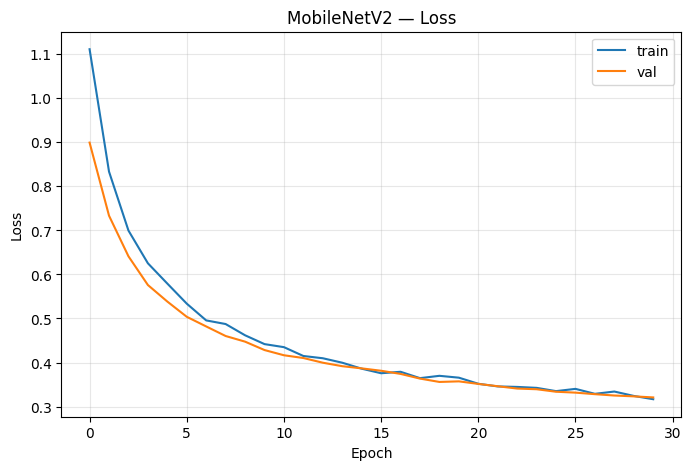

In [ ]:
plot_accuracy(hist_mnv2, "MobileNetV2")
plot_loss(hist_mnv2, "MobileNetV2")

## 14) Evaluate on PRIVATE test set (accuracy + confusion matrix)



------------------------------------------------------------
RESNET50 — PRIVATE TEST RESULTS
------------------------------------------------------------
Accuracy        : 0.8008474576271186
Macro Precision : 0.8016057020857511
Macro Recall    : 0.8042611545922805
Macro F1        : 0.8002100519165523


,class,precision,recall,f1,support
0,glass,0.764706,0.833333,0.797546,156
1,metal,0.834356,0.900662,0.866242,151
2,plastic,0.805755,0.678788,0.736842,165


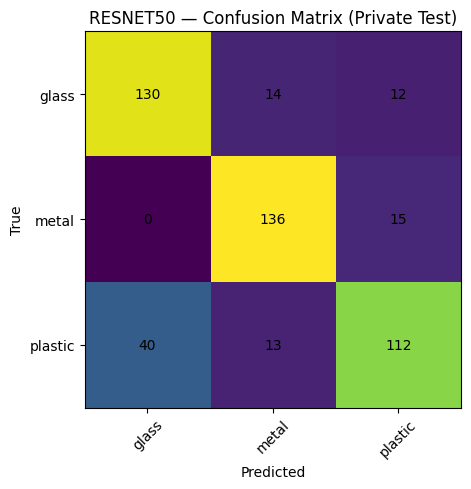


------------------------------------------------------------
VGG16 — PRIVATE TEST RESULTS
------------------------------------------------------------
Accuracy        : 0.5889830508474576
Macro Precision : 0.6333465395462174
Macro Recall    : 0.5868524779120806
Macro F1        : 0.5744855634561518


,class,precision,recall,f1,support
0,glass,0.750000,0.326923,0.455357,156
1,metal,0.639752,0.682119,0.660256,151
2,plastic,0.510288,0.751515,0.607843,165


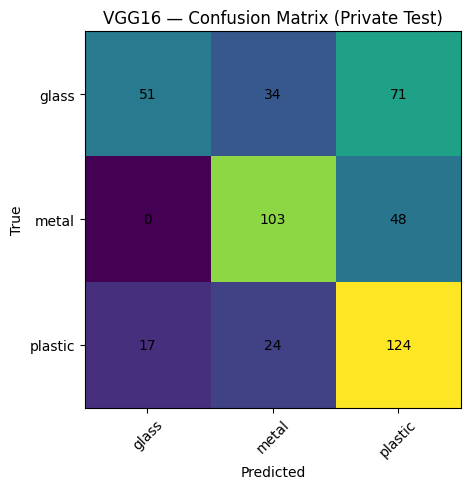


------------------------------------------------------------
MOBILENETV2 — PRIVATE TEST RESULTS
------------------------------------------------------------
Accuracy        : 0.7457627118644068
Macro Precision : 0.7443450687833373
Macro Recall    : 0.7499377370238297
Macro F1        : 0.7452401236114591


,class,precision,recall,f1,support
0,glass,0.715976,0.775641,0.744615,156
1,metal,0.819876,0.874172,0.846154,151
2,plastic,0.697183,0.600000,0.644951,165


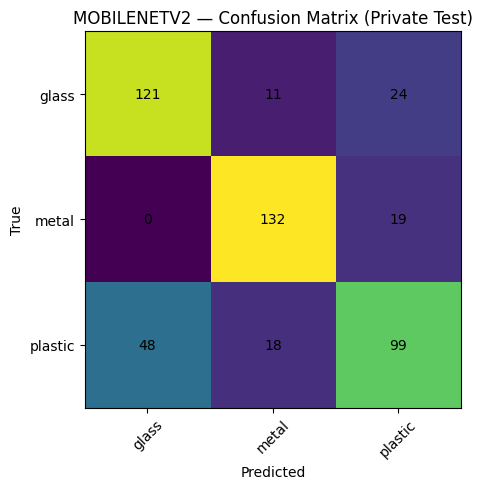

In [ ]:
def predict_labels(model, dataset):
    y_true = []
    y_pred = []
    for x, y in dataset:
        preds = model.predict(x, verbose=0)
        y_true.extend(np.argmax(y.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)

def classification_metrics(y_true, y_pred, num_classes):
    cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()
    acc = float((y_true == y_pred).mean())

    precisions, recalls, f1s, supports = [], [], [], []
    for i in range(num_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        support = cm[i, :].sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        precisions.append(float(precision))
        recalls.append(float(recall))
        f1s.append(float(f1))
        supports.append(int(support))

    macro_p = float(np.mean(precisions))
    macro_r = float(np.mean(recalls))
    macro_f = float(np.mean(f1s))
    return acc, cm, precisions, recalls, f1s, supports, macro_p, macro_r, macro_f

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.yticks(range(len(class_names)), class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

results = {}

if test_ds is None:
    print("[SKIP] No private test dataset found.")
elif len(trained) == 0:
    print("[SKIP] No trained models found. Train a model first.")
else:
    for name, model in trained.items():
        y_true, y_pred = predict_labels(model, test_ds)
        acc, cm, p, r, f1, sup, mp, mr, mf1 = classification_metrics(
            y_true, y_pred, num_classes=len(CLASSES)
        )

        results[name] = {
            "accuracy": acc,
            "macro_precision": mp,
            "macro_recall": mr,
            "macro_f1": mf1,
        }

        print("\n" + "-" * 60)
        print(f"{name.upper()} — PRIVATE TEST RESULTS")
        print("-" * 60)
        print("Accuracy        :", acc)
        print("Macro Precision :", mp)
        print("Macro Recall    :", mr)
        print("Macro F1        :", mf1)

        per_class_df = pd.DataFrame({
            "class": CLASSES,
            "precision": p,
            "recall": r,
            "f1": f1,
            "support": sup,
        })
        display(per_class_df)

        plot_confusion_matrix(cm, CLASSES, title=f"{name.upper()} — Confusion Matrix (Private Test)")

## 15) Summary table (PRIVATE test)


In [ ]:
if results:
    summary_df = pd.DataFrame(results).T.sort_values("accuracy", ascending=False)
    display(summary_df)
else:
    print("No results yet. (Either you haven't tested, or PRIVATE_DIR is missing.)")

,accuracy,macro_precision,macro_recall,macro_f1
resnet50,0.800847,0.801606,0.804261,0.800210
mobilenetv2,0.745763,0.744345,0.749938,0.745240
vgg16,0.588983,0.633347,0.586852,0.574486
